In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. LOAD DATASET

X = np.load("D:/PomegranateGuard/dataset/X.npy")
y = np.load("D:/PomegranateGuard/dataset/y.npy")

print("Dataset loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)

D:\Anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Dataset loaded
X shape: (5626, 224, 224, 3)
y shape: (5626,)


In [2]:
# 2. NORMALIZE IMAGES
X = X.astype("float32") / 255.0
print("Images normalized")

# 3. CHECK CLASS DISTRIBUTION
unique, counts = np.unique(y, return_counts=True)

print("\nClass distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} samples")

Images normalized

Class distribution:
Class 0: 1450 samples
Class 1: 1000 samples
Class 2: 1166 samples
Class 3: 2010 samples


In [3]:
# 4. TRAIN / VALIDATION / TEST SPLIT

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("\nDataset split complete")

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)



Dataset split complete
Train shape: (3938, 224, 224, 3)
Validation shape: (844, 224, 224, 3)
Test shape: (844, 224, 224, 3)


In [4]:
# 6. DATA AUGMENTATION

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

datagen.fit(X_train)

print("Data augmentation ready")

Data augmentation ready


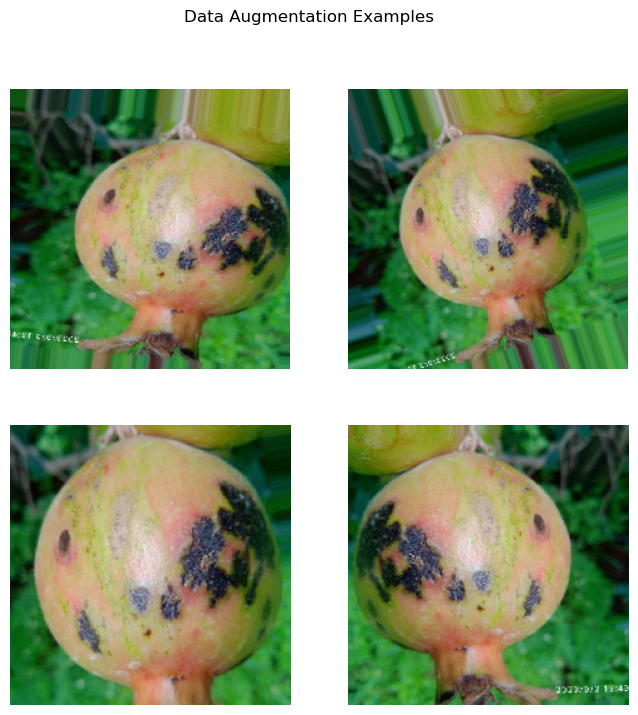

Data preparation complete


In [10]:
# 7. VISUALIZE AUGMENTATION

sample = X_train[0]
sample = np.expand_dims(sample, axis=0)

aug_iter = datagen.flow(sample, batch_size=1)

plt.figure(figsize=(8,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    img = next(aug_iter)[0]
    plt.imshow(img * 255)
    plt.axis("off")

plt.suptitle("Data Augmentation Examples")
plt.show()

print("Data preparation complete")